# Unidad 2: Aprendizaje Automático
## Máquinas de Vectores de Soporte (SVM)
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/25_SVM.ipynb)

## 🎯 ¿Qué vamos a aprender?

Las **Máquinas de Vectores de Soporte** (*Support Vector Machines*, SVM) son uno de los algoritmos de clasificación más poderosos y versátiles. Buscan el **hiperplano de margen máximo** que separa las clases.

Al finalizar, vas a poder:
- ✅ Entender el concepto de **hiperplano separador** y **margen máximo**
- ✅ Identificar qué son los **vectores de soporte**
- ✅ Aplicar SVM con distintos **kernels** (RBF, lineal, polinomial)
- ✅ Evaluar modelos SVM con métricas (Accuracy, Precision, Recall)
- ✅ Visualizar las **fronteras de decisión** en un espacio 2D

---

## 🧠 Marco Teórico

### 📐 ¿Qué es una SVM?

Una SVM busca el **hiperplano** que separa dos clases con el **mayor margen posible**.

```
Feature 2
↑    
|   ●                              ● = Clase A
|    ●   ← margen →               ○ = Clase B
|  ●  
| ════════════════ Hiperplano
|               ○
|             ○   ○
|                ○
└───────────────────────── Feature 1
     ↑          ↑
 Vectores de soporte = muestras más cercanas al hiperplano
```

La SVM maximiza el margen $\frac{2}{||w||}$, sujeto a que todas las muestras estén correctamente clasificadas:

$$y_i(w \cdot x_i + b) \geq 1 \quad \forall i$$

### 🎛️ El truco del Kernel

Cuando los datos **no son linealmente separables**, SVM aplica el **"kernel trick"**: transforma los datos a un espacio de mayor dimensión donde sí pueden separarse linealmente.

| Kernel | Función | Cuándo usar |
|--------|---------|-------------|
| **Lineal** | $K(x,z) = x \cdot z$ | Datos linealmente separables, alta dimensionalidad |
| **RBF** (Gaussiano) | $K(x,z) = e^{-\gamma \|x-z\|^2}$ | Caso general; frontera no lineal |
| **Polinomial** | $K(x,z) = (x \cdot z + c)^d$ | Relaciones polinomiales entre features |

### ⚖️ El parámetro C (regularización)

- **C grande**: margen más pequeño, menos errores en training → riesgo de overfitting
- **C pequeño**: margen más grande, permite más errores → mayor generalización

> ⚠️ Al igual que KNN, **SVM es muy sensible a la escala de las features**. Siempre estandarizar antes de entrenar.

> 📌 **Referencia:** [scikit-learn — Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)

---

## 📦 Paso 1: Importar las Librerías

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 🎗️ Paso 2: Dataset Breast Cancer — Clasificación con SVM

El dataset **Breast Cancer Wisconsin** de scikit-learn contiene características de imágenes de células tumorales para predecir si un tumor es **maligno (0)** o **benigno (1)**.

- 569 muestras, 30 features (radio, textura, perímetro, área, suavidad, etc.)
- Problema binario: maligno vs. benigno

In [9]:
# Cargar el dataset
cancer = datasets.load_breast_cancer()

print('🎗️  Dataset Breast Cancer Wisconsin:')
print(f'  Features ({len(cancer.feature_names)}): {cancer.feature_names[:6]} ...')
print(f'  Clases:   {list(cancer.target_names)}  (0=maligno, 1=benigno)')
print(f'  Forma:    {cancer.data.shape}')

# División: 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target,
    test_size=0.3,
    random_state=109
)

print(f'\n✂️  Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras')

🎗️  Dataset Breast Cancer Wisconsin:
  Features (30): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness'] ...
  Clases:   [np.str_('malignant'), np.str_('benign')]  (0=maligno, 1=benigno)
  Forma:    (569, 30)

✂️  Entrenamiento: 398 muestras | Prueba: 171 muestras


## 🎛️ Paso 3: Comparar Kernels de SVM

Probamos los tres kernels más comunes para ver cuál se adapta mejor a este dataset.

> 💡 `svm.SVC()` sin argumentos usa el **kernel RBF** (Radial Basis Function, también conocido como kernel Gaussiano) por defecto.

In [10]:
# Definir los tres clasificadores con distintos kernels
modelos = {
    'RBF (Gaussiano)': svm.SVC(kernel='rbf'),
    'Lineal':          svm.SVC(kernel='linear'),
    'Polinomial':      svm.SVC(kernel='poly'),
}

print('📊 Comparación de kernels SVM — Breast Cancer Dataset')
print('=' * 55)

resultados_svm = {}
for nombre, clf in modelos.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc  = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec  = metrics.recall_score(y_test, y_pred)
    f1   = metrics.f1_score(y_test, y_pred)
    resultados_svm[nombre] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}
    print(f'  🔷 Kernel {nombre}:')
    print(f'     Accuracy:  {acc:.4f}  ({acc*100:.1f}%)')
    print(f'     Precision: {prec:.4f}   Recall: {rec:.4f}   F1: {f1:.4f}')
    print()

📊 Comparación de kernels SVM — Breast Cancer Dataset
  🔷 Kernel RBF (Gaussiano):
     Accuracy:  0.9240  (92.4%)
     Precision: 0.8926   Recall: 1.0000   F1: 0.9432

  🔷 Kernel Lineal:
     Accuracy:  0.9649  (96.5%)
     Precision: 0.9811   Recall: 0.9630   F1: 0.9720

  🔷 Kernel Polinomial:
     Accuracy:  0.9181  (91.8%)
     Precision: 0.8852   Recall: 1.0000   F1: 0.9391



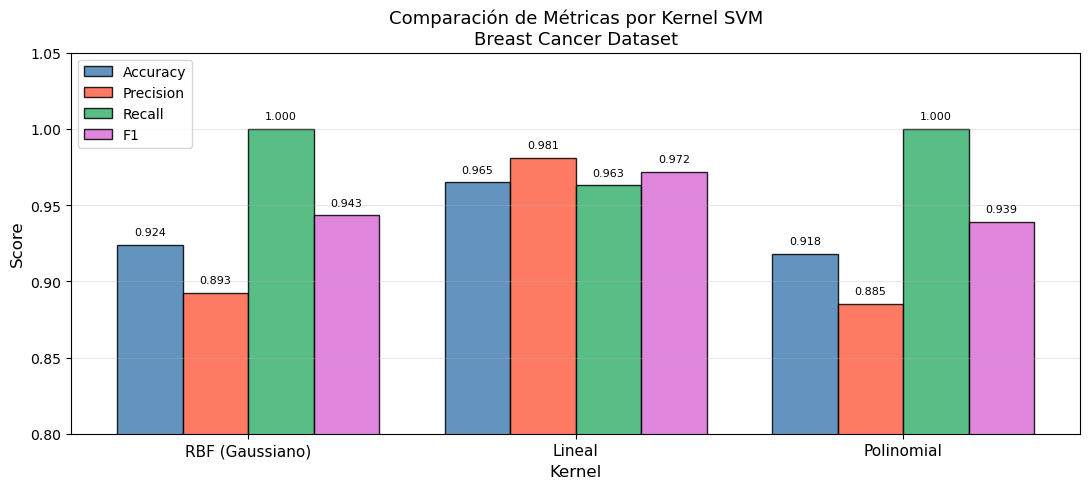

In [11]:
# Visualizar la comparación de métricas
nombres = list(resultados_svm.keys())
metricas_keys = ['acc', 'prec', 'rec', 'f1']
metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(nombres))
width = 0.2
colors = ['steelblue', 'tomato', 'mediumseagreen', 'orchid']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (key, label, color) in enumerate(zip(metricas_keys, metricas_labels, colors)):
    vals = [resultados_svm[n][key] for n in nombres]
    bars = ax.bar(x + i * width, vals, width, label=label, color=color,
                  edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Kernel', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación de Métricas por Kernel SVM\nBreast Cancer Dataset', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylim(0.8, 1.05)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🖼️ Paso 4: Visualización de la Frontera de Decisión

Para mantener consistencia con el notebook, usamos el mismo dataset **Breast Cancer Wisconsin** y lo proyectamos a **2 features** (las dos primeras) para poder visualizar la frontera de decisión en 2D.

> 💡 En la vida real, los modelos trabajan con muchas más dimensiones. Esta visualización es didáctica para entender la intuición geométrica de SVM.

In [12]:
# Usar el mismo dataset de cáncer y quedarnos con 2 features para graficar
X_cancer_2d = cancer.data[:, :2]   # mean radius y mean texture
y_cancer = cancer.target

print('🎗️ Dataset Breast Cancer (2 features para visualización):')
print(f'  Features usadas: {list(cancer.feature_names[:2])}')
print(f'  Clases: {list(cancer.target_names)}')
print(f'  Forma de X: {X_cancer_2d.shape}')
print('\n  Primeras 5 muestras:')
print(X_cancer_2d[:5])

🎗️ Dataset Breast Cancer (2 features para visualización):
  Features usadas: [np.str_('mean radius'), np.str_('mean texture')]
  Clases: [np.str_('malignant'), np.str_('benign')]
  Forma de X: (569, 2)

  Primeras 5 muestras:
[[17.99 10.38]
 [20.57 17.77]
 [19.69 21.25]
 [11.42 20.38]
 [20.29 14.34]]


In [13]:
# Entrenar SVM con kernel polinomial sobre la versión 2D del dataset de cáncer
svc = svm.SVC(kernel='poly', C=100)
svc.fit(X_cancer_2d, y_cancer)

print(f'✅ SVM entrenada (kernel=poly, C=100)')
print(f'   Vectores de soporte por clase: {svc.n_support_}')
print(f'   Total vectores de soporte:     {svc.support_vectors_.shape[0]}')

✅ SVM entrenada (kernel=poly, C=100)
   Vectores de soporte por clase: [68 68]
   Total vectores de soporte:     136


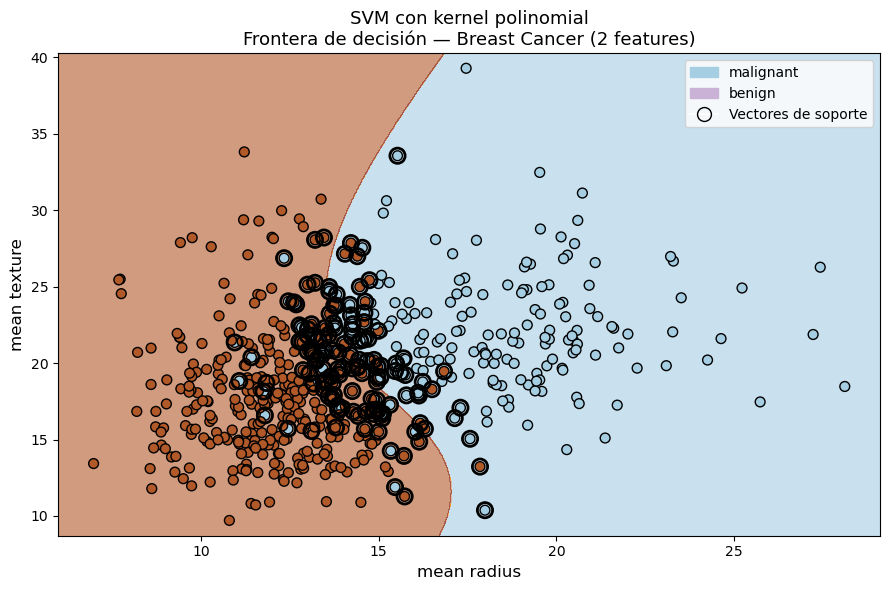


📊 Accuracy en dataset completo (train = test): 0.9033
⚠️  Esta métrica es optimista — el modelo fue entrenado con los mismos datos.
   Para una evaluación real, usar train/test split o validación cruzada.


In [14]:
# Crear una grilla sobre el espacio de features para colorear cada punto según la predicción
x_min, x_max = X_cancer_2d[:, 0].min() - 1, X_cancer_2d[:, 0].max() + 1
y_min, y_max = X_cancer_2d[:, 1].min() - 1, X_cancer_2d[:, 1].max() + 1
h = 0.02   # paso de la grilla

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predecir la clase para cada punto de la grilla
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar la frontera de decisión
fig, ax = plt.subplots(figsize=(9, 6))

ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.6)
scatter = ax.scatter(X_cancer_2d[:, 0], X_cancer_2d[:, 1], c=y_cancer,
                     cmap=plt.cm.Paired, edgecolors='black', s=50)

# Marcar los vectores de soporte
ax.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1],
           s=120, facecolors='none', edgecolors='black', linewidths=2,
           label='Vectores de soporte')

ax.set_xlabel(cancer.feature_names[0], fontsize=12)
ax.set_ylabel(cancer.feature_names[1], fontsize=12)
ax.set_title('SVM con kernel polinomial\nFrontera de decisión — Breast Cancer (2 features)', fontsize=13)

# Leyenda de clases
from matplotlib.patches import Patch
legend_patches = [Patch(color=plt.cm.Paired(v), label=l)
                  for v, l in zip([0, 0.7], cancer.target_names)]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], marker='o', color='w',
          markeredgecolor='black', markerfacecolor='none', markersize=10,
          label='Vectores de soporte')], fontsize=10)

plt.tight_layout()
plt.show()

acc_full = svc.score(X_cancer_2d, y_cancer)
print(f'\n📊 Accuracy en dataset completo (train = test): {acc_full:.4f}')
print('⚠️  Esta métrica es optimista — el modelo fue entrenado con los mismos datos.')
print('   Para una evaluación real, usar train/test split o validación cruzada.')

## 🎓 Resumen y Conclusiones

En este notebook aprendimos:

1. 📐 **El concepto de SVM**: hiperplano de margen máximo y vectores de soporte
2. 🎛️ **Los tres kernels principales**: RBF (Gaussiano), lineal y polinomial
3. 📊 **Comparar kernels** con métricas (Accuracy, Precision, Recall, F1)
4. 🖼️ **Visualizar la frontera de decisión** en un espacio 2D con contourf

### Puntos clave

- **SVM es sensible a la escala** → siempre estandarizar antes de entrenar
- El **kernel RBF** (default) es un buen punto de partida en la mayoría de los casos
- El parámetro **C** controla el trade-off entre margen y errores de clasificación
- Los **vectores de soporte** son las únicas muestras que definen el hiperplano

### 🚀 ¿Qué sigue?

- 🔧 **GridSearchCV**: encontrar los mejores hiperparámetros (kernel, C, gamma) de forma automática
- 🔢 **StandardScaler + SVM**: comparar el rendimiento con y sin estandarización
- 📉 **Reducción de dimensionalidad (PCA)**: visualizar datasets de alta dimensionalidad

> 📚 **Referencias:**
> - [scikit-learn — Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)
> - [scikit-learn — SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
> - Cortes, C. & Vapnik, V. (1995). [Support-vector networks](https://doi.org/10.1007/BF00994018). *Machine Learning*, 20(3), 273–297.
> - Schölkopf, B. & Smola, A. (2002). *Learning with Kernels*. MIT Press.

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).